In [1]:
from Montreal_UHI_toolbox import *
from sklearn.linear_model import LinearRegression

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
stations = stations.drop_vars(['lake_fraction_blurred_std1p5','urban_fraction_blurred_std1p5'])

In [3]:
path = '/runoff/gulley/St_Laurent/intermediates/station' # move tasmin to /runoff/gulley/St_Laurent/intermediates/station
avgs = {}
stds = {}
for field in ['tasmax','tas','tasmin']:
    avgs[field] = xr.open_zarr(f'{path}/seasons_avg_{field}.zarr')[field].drop_vars(['urban_fraction','lake_fraction','lake_fraction_blurred_std1p5','urban_fraction_blurred_std1p5'])
    stds[field] = xr.open_zarr(f'{path}/seasons_std_{field}.zarr')[field].drop_vars(['urban_fraction','lake_fraction','lake_fraction_blurred_std1p5','urban_fraction_blurred_std1p5'])
    

In [5]:
for field in ['tasmax','tas','tasmin']:
    avgs[field] = avgs[field].assign_coords({'elev': stations.elev})
    stds[field] = stds[field].assign_coords({'elev': stations.elev})

all_geophys = []
orog = xr.open_mfdataset('/runoff/gulley/St_Laurent/StLaurent_1km_SL2.5_ERA5_advHU/Fix_Fields/StLaurent_1km_SL2.5_ERA5_advHU_orog.nc')
all_geophys.append(orog['lat'])
all_geophys.append(orog['lon'])
all_geophys.append(orog['orog'].rename('elev'))

In [7]:
# Add (blurred) CLASS fields 
for lev in veg_levs:
    static_field = veg_fields.sel(lev=lev).rename(veg_levs[lev])
    # for field in ['tasmax','tas','tasmin']:
        # avgs[field] = add_blurred_field_to_stations(static_field,sigma=1.5,stations=avgs[field])
        # stds[field] = add_blurred_field_to_stations(static_field,sigma=1.5,stations=stds[field])
    all_geophys.append(static_field)
        # Option to include raw field as a coordinate
        # avgs[field] = add_field_to_stations(static_field,stations=avgs[field])

In [8]:
# Add (blurred) TEB fields
for static_field in TEB_geophys: 
    static_field = static_field.rename(f'{static_field.name}_TEB')
    if 'lev' in static_field.coords:
        static_field = static_field.sel(lev=1) # All levels are identical in the TEB fields so I'll just take the first
        static_field = static_field.rename(f'{static_field.name}_lev1')
    
    # for field in ['tasmax','tas','tasmin']: # Could just setcoords
        # avgs[field] = add_blurred_field_to_stations(static_field,sigma=1.5,stations=avgs[field])
        # stds[field] = add_blurred_field_to_stations(static_field,stations=stds[field])

    all_geophys.append(static_field)
        
        # Option to include raw field as a coordinate
        # avgs[field] = add_field_to_stations(static_field,sigma=1.5,stations=avgs[field])
        

In [28]:
# CLASS or TEB fields which would not be beneficial to analyse due to unusual spatial distribution
exclude = ['salt water, ocean',
    'glacier',
    'tropical broadleaf trees',
    'drought deciduous trees',
    'thorn shrubs',
    'long grass',
    'rice',
    'sugar',
    'maize',
    'cotton',
    'irrigated crops',
    'tundra',
    'swamp',
    'road_roughness_TEB',
    'roof_thermal_cond_TEB_lev1',
    'wall_thermal_cond_TEB_lev1',
    'industry_shfx_TEB',
    'industry_lhfx_TEB']
already_in_stations = ['lat','lon','elev']
all_geophys = [field for field in all_geophys if field.name not in exclude]
p = [field for field in all_geophys if field.name not in already_in_stations]

# Observational station data to be analysed
obs = avgs['tasmin'].sel(season='JJA')
obs_std = stds['tasmin'].sel(season='JJA')
for field in p:
    obs = add_blurred_field_to_stations(field,stations=obs)
obs = obs.dropna(dim='station')

In [30]:
predictors = []

data = obs
errs = obs_std
for coord in data.coords:
    x = data[coord].values
    y = data.values
    names = list(data['station_name'].values)
    yerr = errs.values
    
    if(np.shape(x) == np.shape(y) and (data[coord].dtype == 'float64' or data[coord].dtype == 'float32')):
        if coord not in predictors:
            predictors.append(coord)
            
        # model = LinearRegression()
        # X = x.reshape(-1, 1)
        # model.fit(X,y)
        # r_square = model.score(X,y)
        # # if r_square >= 0.4: # Ignore weakest linear correlations            
            
        # if r_square >= 0.: # Ignore weakest linear correlations            
            
        #     # plt.title(season)
        #     plt.ylabel(field)
        #     plt.xlabel(coord)
            
        #     # plt.plot(x,y,'.',color='black',label=field)
        #     plt.errorbar(x, y, yerr=yerr, fmt='.',color='black', ecolor='gray', capsize=5, capthick=2)
            
        #     xline = np.linspace(min(x),max(x),2)
        #     yline = xline*model.coef_ + model.intercept_
        #     plt.plot(xline,yline,'b')
        #     plt.title(f'y={round(model.coef_[0]*10)/10}x+{round(model.intercept_*10)/10}, R²={round(r_square*100)/100}')
        #     for x_pos,y_pos,stn_name in zip (x,y,names):
        #         plt.text(x_pos, y_pos, stn_name,size='xx-small')
        # # plt.show()

In [11]:
# field_map = {
#     "lat": "lat",
#     "lon": "lon",
#     "orog": "elev",
#     "salt water, ocean": "salt_water_ocean_blurred_std1p5",
#     "glacier": "glacier_blurred_std1p5",
#     "inland lake": "inland_lake_blurred_std1p5",
#     "evergreen needle-leaf trees": "evergreen_needle-leaf_trees_blurred_std1p5",
#     "evergreen broadleaf trees": "evergreen_broadleaf_trees_blurred_std1p5",
#     "deciduous needle-leaf trees": "deciduous_needle-leaf_trees_blurred_std1p5",
#     "deciduous broadleaf trees": "deciduous_broadleaf_trees_blurred_std1p5",
#     "tropical broadleaf trees": "tropical_broadleaf_trees_blurred_std1p5",
#     "drought deciduous trees": "drought_deciduous_trees_blurred_std1p5",
#     "evergreen broadleaf shrubs": "evergreen_broadleaf_shrubs_blurred_std1p5",
#     "deciduous shrubs": "deciduous_shrubs_blurred_std1p5",
#     "thorn shrubs": "thorn_shrubs_blurred_std1p5",
#     "short grass and forbs": "short_grass_and_forbs_blurred_std1p5",
#     "long grass": "long_grass_blurred_std1p5",
#     "crops": "crops_blurred_std1p5",
#     "rice": "rice_blurred_std1p5",
#     "sugar": "sugar_blurred_std1p5",
#     "maize": "maize_blurred_std1p5",
#     "cotton": "cotton_blurred_std1p5",
#     "irrigated crops": "irrigated_crops_blurred_std1p5",
#     "urban": "urban_fraction_blurred_std1p5",
#     "tundra": "tundra_blurred_std1p5",
#     "swamp": "swamp_blurred_std1p5",
#     "desert / bare soil": "desert_or_bare_soil_blurred_std1p5",
#     "mixed wood forests": "mixed_wood_forests_blurred_std1p5",
#     "mixed shrubs": "mixed_shrubs_blurred_std1p5",
#     "natural_frac_TEB": "natural_frac_TEB_blurred_std1p5",
#     "building_frac_TEB": "building_frac_TEB_blurred_std1p5",
#     "building_height_TEB": "building_height_TEB_blurred_std1p5",
#     "road_frac_TEB": "road_frac_TEB_blurred_std1p5",
#     "roof_roughness_TEB": "roof_roughness_TEB_blurred_std1p5",
#     "road_roughness_TEB": "road_roughness_TEB_blurred_std1p5",
#     "roof_albedo_TEB": "roof_albedo_TEB_blurred_std1p5",
#     "road_albedo_TEB": "road_albedo_TEB_blurred_std1p5",
#     "wall_albedo_TEB": "wall_albedo_TEB_blurred_std1p5",
#     "roof_emiss_TEB": "roof_emiss_TEB_blurred_std1p5",
#     "road_emiss_TEB": "road_emiss_TEB_blurred_std1p5",
#     "wall_emiss_TEB": "wall_emiss_TEB_blurred_std1p5",
#     "roof_heat_cap_TEB_lev1": "roof_heat_cap_TEB_lev1_blurred_std1p5",
#     "road_heat_cap_TEB_lev1": "road_heat_cap_TEB_lev1_blurred_std1p5",
#     "wall_heat_cap_TEB_lev1": "wall_heat_cap_TEB_lev1_blurred_std1p5",
#     "roof_thermal_cond_TEB_lev1": "roof_thermal_cond_TEB_lev1_blurred_std1p5",
#     "road_thermal_cond_TEB_lev1": "road_thermal_cond_TEB_lev1_blurred_std1p5",
#     "wall_thermal_cond_TEB_lev1": "wall_thermal_cond_TEB_lev1_blurred_std1p5",
#     "roof_layer_depth_TEB_lev1": "roof_layer_depth_TEB_lev1_blurred_std1p5",
#     "road_layer_depth_TEB_lev1": "road_layer_depth_TEB_lev1_blurred_std1p5",
#     "wall_layer_depth_TEB_lev1": "wall_layer_depth_TEB_lev1_blurred_std1p5",
#     "traffic_shfx_TEB": "traffic_shfx_TEB_blurred_std1p5",
#     "traffic_lhfx_TEB": "traffic_lhfx_TEB_blurred_std1p5",
#     "industry_shfx_TEB": "industry_shfx_TEB_blurred_std1p5",
#     "industry_lhfx_TEB": "industry_lhfx_TEB_blurred_std1p5",
#     "town_roughness_TEB": "town_roughness_TEB_blurred_std1p5",
#     "ratio_vert_hor_TEB": "ratio_vert_hor_TEB_blurred_std1p5",
#     "urban" : "urban_blurred_std1p5"
# }
# # station_to_model[['lake_fraction_blurred_std1p5',

# # station_to_model['urban_blurred_std1p5'] = 'urban'

# station_to_model = {v: k for k, v in field_map.items()}
# # station_to_model['lake_fraction_blurred_std1p5'] = 'inland lake'
# # station_to_model['urban_fraction_blurred_std1p5'] = 'urban'
# # station_to_model['urban_blurred_std1p5'] = 'urban'

In [31]:
scaler = StandardScaler() # For going between unitless/temperature space
da = obs
X = np.column_stack([da.coords[var].values for var in predictors]) 
y = da.values 
model = make_pipeline(scaler, Ridge(alpha=1.0)) 
model.fit(X, y) 
ridge = model.named_steps['ridge'] 
print('Coefficients', ridge.coef_)

Coefficients [-0.38963683 -0.10560777 -0.08514994  0.11142434 -0.56160764  0.09589978
  0.13019818 -0.10108686 -0.05629924 -0.22448529  0.16926244 -0.01995529
  0.31108048 -0.22563     0.14532974 -0.07166627  0.02082629  0.00968838
 -0.0683673  -0.0367626  -0.00772885 -0.06892792  0.21283657  0.14647139
 -0.00507915 -0.05440443  0.0011751  -0.04372341 -0.0086013   0.0225172
 -0.06016935 -0.05820894 -0.00931435  0.05110365 -0.06880041 -0.06880041
  0.05774255  0.10924394]


In [35]:
# Going back into temperature space
coefs = ridge.coef_  
intercept = ridge.intercept_
betas = coefs / scaler.scale_
# intercept_adj = intercept - np.sum(scaler.mean_ * betas)
intercept_adj = intercept - np.dot(betas, scaler.mean_)

In [58]:
print(f'{intercept_adj}')
for i,name in enumerate(predictors):
    print(f'+ {betas[i]} * [{all_geophys[i].name}]')

40.26907311430731
+ -0.763005788292498 * [lat]
+ -0.11718968700877382 * [lon]
+ -0.000923195688528878 * [elev]
+ 1.0891074536028833 * [inland lake]
+ -10.127009829030364 * [evergreen needle-leaf trees]
+ 7.616081744667287 * [evergreen broadleaf trees]
+ 6.180388478949302 * [deciduous needle-leaf trees]
+ -0.7380013085487297 * [deciduous broadleaf trees]
+ -4.147530590939858 * [evergreen broadleaf shrubs]
+ -8.276495089166524 * [deciduous shrubs]
+ 4.6865261581864015 * [short grass and forbs]
+ -0.08080949474519343 * [crops]
+ 2.0939542133836513 * [urban]
+ -5.601312825465489 * [desert / bare soil]
+ 27.582485601364233 * [mixed wood forests]
+ -5.296526800387652 * [mixed shrubs]
+ 0.17006167199995842 * [natural_frac_TEB]
+ 0.223412527679566 * [building_frac_TEB]
+ -0.03148772047328276 * [building_height_TEB]
+ -0.4549406145746988 * [road_frac_TEB]
+ -0.23130725777164926 * [roof_roughness_TEB]
+ -2.0370649982515596 * [roof_albedo_TEB]
+ 5.855543042797524 * [road_albedo_TEB]
+ 2.540980547

In [38]:
grid_pred = xr.zeros_like(orog['orog'].rename('')) + intercept_adj
for beta, field in zip(betas, all_geophys):
    grid_pred = grid_pred + beta * field

In [47]:
import Montreal_UHI_toolbox as tools

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: >,
 <matplotlib.colorbar.Colorbar at 0x2b3652da2c90>)

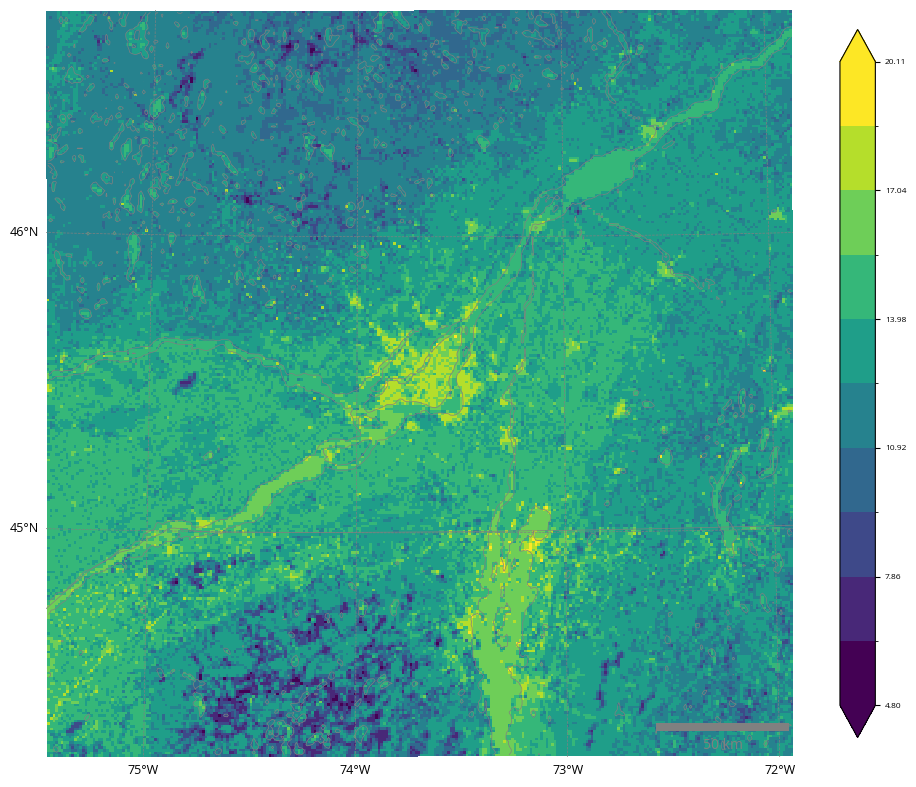

In [56]:
plot_field(grid_pred)

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: >,
 <matplotlib.colorbar.Colorbar at 0x2b366bdaa390>)

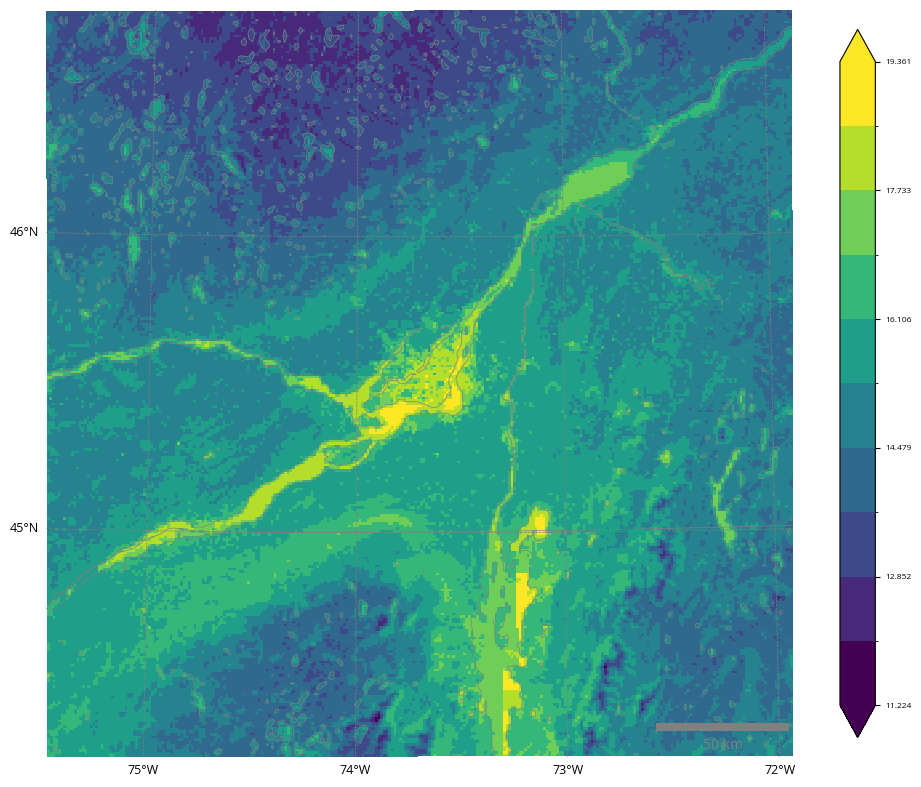

In [57]:
# Loading the simulated averages to compare
field = 'tasmin'
path = '/runoff/gulley/St_Laurent/intermediates'
summer = {}
summer[f'{field}_C'] = xr.open_zarr(f'{path}/sim/seasons_avg_{field}_noTEB.zarr')[field].sel(season='JJA') - 273.15
summer[f'{field}_T'] = xr.open_zarr(f'{path}/sim/seasons_avg_{field}_TEB.zarr')[field].sel(season='JJA') - 273.15

plot_field(summer['tasmin_T'])